## 用卷积神经网络训练Cifar10
For this tutorial, we will use the CIFAR10 dataset. It has the classes: ‘airplane’, ‘automobile’, ‘bird’, ‘cat’, ‘deer’, ‘dog’, ‘frog’, ‘horse’, ‘ship’, ‘truck’. The images in CIFAR-10 are of size 3x32x32, i.e. 3-channel color images of 32x32 pixels in size.

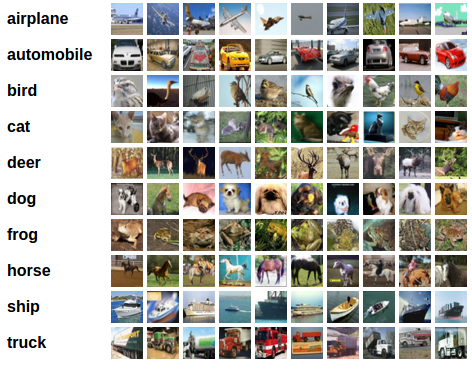

## Training an image classifier
We will do the following steps in order:
- Load and normalize the CIFAR10 training and test datasets using torchvision
- Define a Convolutional Neural Network
- Define a loss function
- Train the network on the training data
- Test the network on the test data

## 1. Load and normalize CIFAR10
Using torchvision, it's extremely easy to load CIFAR10.

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms

The output of torchvision datasets are PILImage images of range [0, 1]. We transform them to Tensors of normalized range [-1, 1].

In [4]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Let us show some of the training images, for fun.

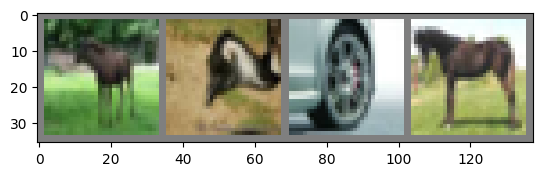

deer  bird  car   horse


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

## 2. Define a Convolutional Neural Network


In [6]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5) # 4, 6, 28, 28
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
#         x = self.conv1(x)
#         print("output shape of conv1:", x.size())
#         x = F.relu(x)
        
#         x = self.pool(x)
        
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

## 3. Define a Loss function and optimizer
Let’s use a Classification Cross-Entropy loss and SGD with momentum.

In [7]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

## 4. Train the network
This is when things start to get interesting. We simply have to loop over our data iterator, and feed the inputs to the network and optimize.

In [8]:
for epoch in range(2):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 2.200
[1,  4000] loss: 1.894
[1,  6000] loss: 1.694
[1,  8000] loss: 1.559
[1, 10000] loss: 1.511
[1, 12000] loss: 1.448
[2,  2000] loss: 1.380
[2,  4000] loss: 1.340
[2,  6000] loss: 1.314
[2,  8000] loss: 1.297
[2, 10000] loss: 1.283
[2, 12000] loss: 1.247
Finished Training


Let’s quickly save our trained model:

In [9]:
PATH = './cifar_net.pth'
torch.save(net.state_dict(), PATH)

## 5. Test the network on the test data
We have trained the network for 2 passes over the training dataset. But we need to check if the network has learnt anything at all.

We will check this by predicting the class label that the neural network outputs, and checking it against the ground-truth. If the prediction is correct, we add the sample to the list of correct predictions.

Okay, first step. Let us display an image from the test set to get familiar.

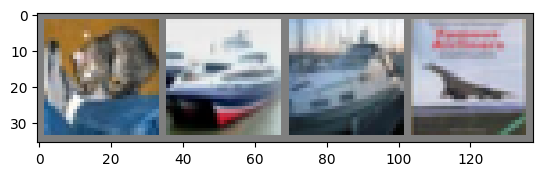

GroundTruth:  cat   ship  ship  plane


In [10]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

Next, let’s load back in our saved model (note: saving and re-loading the model wasn’t necessary here, we only did it to illustrate how to do so):

In [12]:
net = Net()
net.load_state_dict(torch.load(PATH))

<All keys matched successfully>

Okay, now let us see what the neural network thinks these examples above are:

In [13]:
outputs = net(images)

The outputs are energies for the 10 classes. The higher the energy for a class, the more the network thinks that the image is of the particular class. So, let’s get the index of the highest energy:

In [14]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(4)))

Predicted:  frog  car   car   ship 


The results seem pretty good.

Let us look at how the network performs on the whole dataset.

In [15]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 53 %


That looks way better than chance, which is 10% accuracy (randomly picking a class out of 10 classes). Seems like the network learnt something.

Hmmm, what are the classes that performed well, and the classes that did not perform well:

In [16]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 59.2 %
Accuracy for class: car   is 62.7 %
Accuracy for class: bird  is 39.5 %
Accuracy for class: cat   is 23.9 %
Accuracy for class: deer  is 36.6 %
Accuracy for class: dog   is 42.3 %
Accuracy for class: frog  is 78.6 %
Accuracy for class: horse is 57.9 %
Accuracy for class: ship  is 57.5 %
Accuracy for class: truck is 78.2 %


---
# 6. 统一对比实验：CNN / ResNet / DenseNet / MobileNet / Res2Net

上面是老师提供的原始 CNN（baseline）。下面按作业要求，加入自己实现的 **ResNet / DenseNet / MobileNet**，以及扩展部分的 **Res2Net**，在**同一套训练协议**下做对比。

**代码结构**
- 模型定义在 [`models.py`](models.py)，统一用 `build_model(name)` 构建（CIFAR 32×32 适配版）；
- 数据 / 训练 / 评估工具在 [`train_utils.py`](train_utils.py)，训练循环沿用老师的写法（`CrossEntropyLoss` + `SGD(momentum)` + 标准 mini-batch 循环），只是每个 epoch 末记录 `train_loss / test_loss / test_acc` 以便画曲线；
- 本 notebook 负责：构建模型 → 打印结构 → 训练 → **可视化对比**。

> 为公平对比，5 个模型都用「数据增强 + 相同 epoch / 优化器 / 随机种子」训练；baseline 也用同协议重训一遍，因此它的准确率会高于上面教程里只跑 2 个 epoch 的 53%。

In [11]:
import importlib
import json, os, time

import torch
import numpy as np
import matplotlib.pyplot as plt

# matplotlib 显示中文
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

import models, train_utils
importlib.reload(models)      # 改了 .py 后重跑这一格即可生效
importlib.reload(train_utils)
from models import build_model, DISPLAY_NAMES
from train_utils import (get_dataloaders, get_device, set_seed, train_model,
                         evaluate, per_class_accuracy, count_parameters, CLASSES)

# ---------------- 实验配置（按需修改）----------------
CONFIG = {
    'model_names': ['cnn', 'resnet', 'densenet', 'mobilenet', 'res2net'],
    'epochs': 30,
    'lr': 0.01,
    'momentum': 0.9,
    'weight_decay': 5e-4,
    'batch_size': 128,
    'augment': True,
    'seed': 42,
}
DEVICE = get_device()
HIST_PATH = './histories.json'   # 训练历史落盘，便于只重跑可视化而不必重训

def model_iter():
    # 按 CONFIG 顺序遍历已有结果 (name, result_dict)
    for name in CONFIG['model_names']:
        if name in results:
            yield name, results[name]

print('device =', DEVICE)
print('config =', CONFIG)

device = cuda
config = {'model_names': ['cnn', 'resnet', 'densenet', 'mobilenet', 'res2net'], 'epochs': 30, 'lr': 0.01, 'momentum': 0.9, 'weight_decay': 0.0005, 'batch_size': 128, 'augment': True, 'seed': 42}


In [12]:
set_seed(CONFIG['seed'])
trainloader_cmp, testloader_cmp = get_dataloaders(
    batch_size=CONFIG['batch_size'], augment=CONFIG['augment'])
print('训练 batch 数:', len(trainloader_cmp), '| 测试 batch 数:', len(testloader_cmp))

训练 batch 数: 391 | 测试 batch 数: 79


## 6.1 各模型网络结构与参数量

作业要求展示每个网络的结构（`print(net)`）。下面同时统计可训练参数量，作为后面“参数量 vs 准确率”对比的依据。

In [13]:
param_table = []
for name in CONFIG['model_names']:
    net = build_model(name)
    n_params = count_parameters(net)
    param_table.append((DISPLAY_NAMES[name], n_params))
    print('=' * 64)
    print(f'[{DISPLAY_NAMES[name]}]  可训练参数量: {n_params:,}')
    print(net)

print('\n参数量汇总：')
for disp, n in param_table:
    print(f'  {disp:12s}: {n / 1e6:.3f} M')

[BaselineCNN]  可训练参数量: 62,006
BaselineCNN(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
[ResNet18]  可训练参数量: 11,173,962
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64,

## 6.2 训练所有模型

> 这一格耗时较长（建议 GPU）。训练历史会存到 `histories.json`，每个模型权重存到 `ckpt_<name>.pth`。
> 已存在历史文件时默认**跳过训练直接加载**；想重训就把 `FORCE_RETRAIN` 设为 `True` 或删除 `histories.json`。

In [14]:
FORCE_RETRAIN = False

if (not FORCE_RETRAIN) and os.path.exists(HIST_PATH):
    with open(HIST_PATH, 'r', encoding='utf-8') as f:
        results = json.load(f)
    print('已从', HIST_PATH, '加载历史，跳过训练。包含模型：', list(results))
else:
    results = {}
    for name in CONFIG['model_names']:
        print('\n' + '#' * 70)
        print('# 训练', DISPLAY_NAMES[name])
        print('#' * 70)
        set_seed(CONFIG['seed'])                  # 每个模型同一初始条件
        net = build_model(name).to(DEVICE)
        t0 = time.time()
        history = train_model(
            net, trainloader_cmp, testloader_cmp,
            epochs=CONFIG['epochs'], lr=CONFIG['lr'],
            momentum=CONFIG['momentum'], weight_decay=CONFIG['weight_decay'],
            device=DEVICE, log_every=200, verbose=True)
        elapsed = time.time() - t0
        pca = per_class_accuracy(net, testloader_cmp, DEVICE)
        results[name] = {
            'display': DISPLAY_NAMES[name],
            'history': history,
            'per_class_acc': pca,
            'params': count_parameters(net),
            'best_acc': max(history['test_acc']),
            'final_acc': history['test_acc'][-1],
            'train_time_sec': elapsed,
        }
        torch.save(net.state_dict(), f'./ckpt_{name}.pth')
        print(f'==> {DISPLAY_NAMES[name]} 完成：best_acc={results[name]["best_acc"]:.2f}%  用时 {elapsed / 60:.1f} 分钟')

    with open(HIST_PATH, 'w', encoding='utf-8') as f:
        json.dump(results, f, ensure_ascii=False, indent=2)
    print('\n训练历史已保存到', HIST_PATH)


######################################################################
# 训练 BaselineCNN
######################################################################
[epoch 1, iter   200] loss: 2.126
  => epoch 1/30  train_loss=1.945  test_loss=1.606  test_acc=41.26%
[epoch 2, iter   200] loss: 1.627
  => epoch 2/30  train_loss=1.589  test_loss=1.402  test_acc=48.76%
[epoch 3, iter   200] loss: 1.481
  => epoch 3/30  train_loss=1.460  test_loss=1.282  test_acc=54.32%
[epoch 4, iter   200] loss: 1.376
  => epoch 4/30  train_loss=1.363  test_loss=1.284  test_acc=54.84%
[epoch 5, iter   200] loss: 1.318
  => epoch 5/30  train_loss=1.310  test_loss=1.181  test_acc=58.00%
[epoch 6, iter   200] loss: 1.279
  => epoch 6/30  train_loss=1.266  test_loss=1.166  test_acc=58.88%
[epoch 7, iter   200] loss: 1.232
  => epoch 7/30  train_loss=1.223  test_loss=1.128  test_acc=60.38%
[epoch 8, iter   200] loss: 1.212
  => epoch 8/30  train_loss=1.199  test_loss=1.110  test_acc=61.08%
[epoch 9, iter   200] lo

## 6.3 可视化对比

依次给出：训练/测试 Loss 曲线、测试准确率曲线、最佳准确率柱状图与“参数量 vs 准确率”、各类别准确率热力图、汇总表。

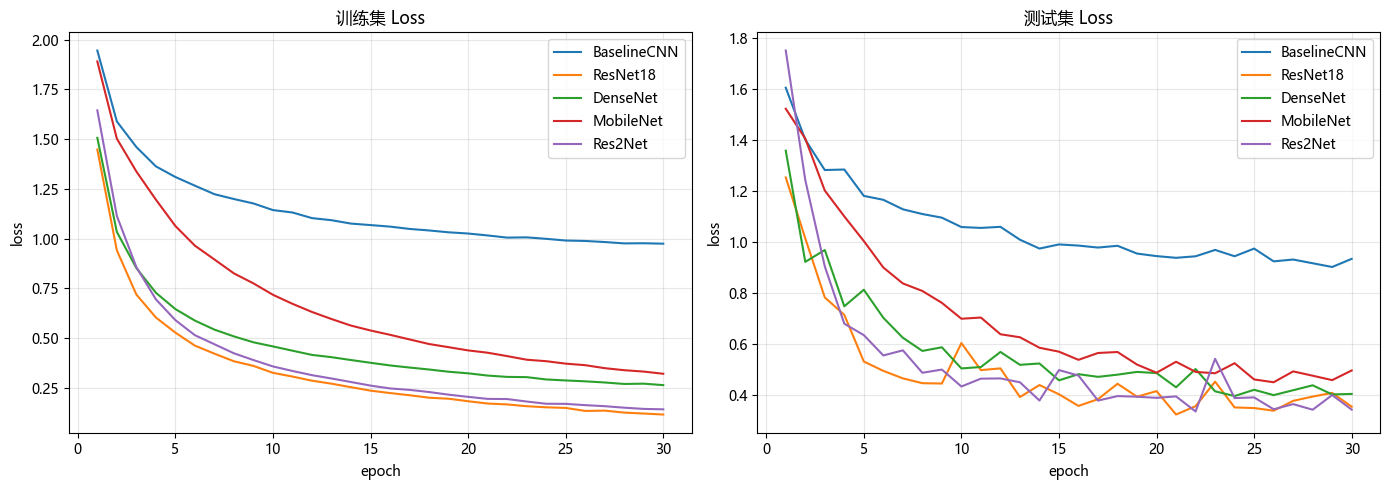

In [15]:
# 训练集 / 测试集 Loss 曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in model_iter():
    ex = range(1, len(r['history']['train_loss']) + 1)
    axes[0].plot(ex, r['history']['train_loss'], label=r['display'])
    axes[1].plot(ex, r['history']['test_loss'], label=r['display'])
axes[0].set_title('训练集 Loss'); axes[1].set_title('测试集 Loss')
for ax in axes:
    ax.set_xlabel('epoch'); ax.set_ylabel('loss'); ax.legend(); ax.grid(True, alpha=.3)
plt.tight_layout(); plt.show()

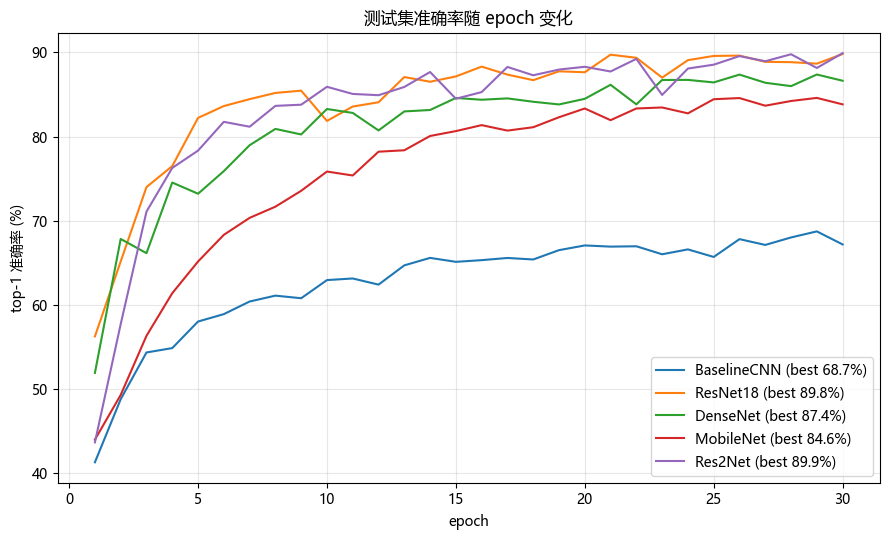

In [16]:
# 测试集准确率曲线
plt.figure(figsize=(9, 5.5))
for name, r in model_iter():
    ex = range(1, len(r['history']['test_acc']) + 1)
    plt.plot(ex, r['history']['test_acc'], label=f"{r['display']} (best {r['best_acc']:.1f}%)")
plt.title('测试集准确率随 epoch 变化'); plt.xlabel('epoch'); plt.ylabel('top-1 准确率 (%)')
plt.legend(); plt.grid(True, alpha=.3); plt.tight_layout(); plt.show()

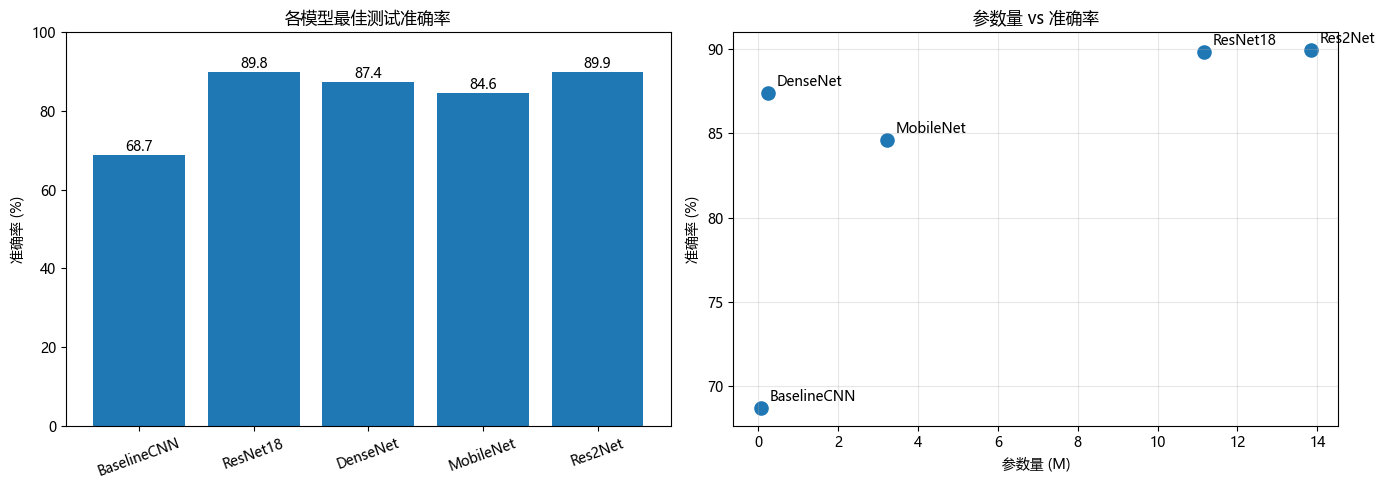

In [17]:
# 最佳准确率柱状图 + 参数量 vs 准确率
disp   = [r['display']        for _, r in model_iter()]
best   = [r['best_acc']       for _, r in model_iter()]
par_m  = [r['params'] / 1e6   for _, r in model_iter()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars = axes[0].bar(disp, best, color='tab:blue')
axes[0].set_title('各模型最佳测试准确率'); axes[0].set_ylabel('准确率 (%)'); axes[0].set_ylim(0, 100)
for b, v in zip(bars, best):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 1, f'{v:.1f}', ha='center')
axes[0].tick_params(axis='x', rotation=20)

axes[1].scatter(par_m, best, s=90)
for x, y, d in zip(par_m, best, disp):
    axes[1].annotate(d, (x, y), textcoords='offset points', xytext=(6, 5))
axes[1].set_title('参数量 vs 准确率'); axes[1].set_xlabel('参数量 (M)'); axes[1].set_ylabel('准确率 (%)')
axes[1].grid(True, alpha=.3)
plt.tight_layout(); plt.show()

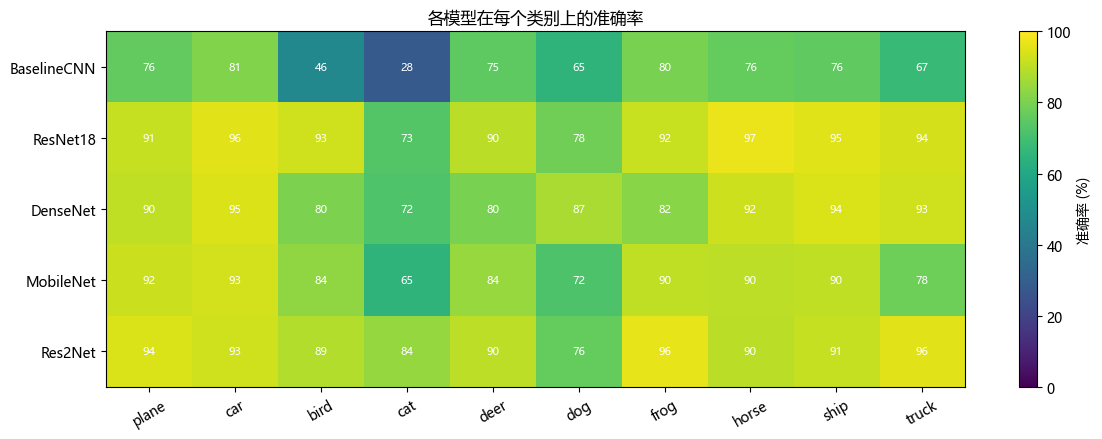

In [18]:
# 各模型在每个类别上的准确率（热力图）
order = [name for name, _ in model_iter()]
mat = np.array([[results[n]['per_class_acc'][c] for c in CLASSES] for n in order])
fig, ax = plt.subplots(figsize=(12, 4.5))
im = ax.imshow(mat, aspect='auto', cmap='viridis', vmin=0, vmax=100)
ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=30)
ax.set_yticks(range(len(order))); ax.set_yticklabels([results[n]['display'] for n in order])
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f'{mat[i, j]:.0f}', ha='center', va='center', color='w', fontsize=8)
fig.colorbar(im, ax=ax, label='准确率 (%)')
ax.set_title('各模型在每个类别上的准确率'); plt.tight_layout(); plt.show()

In [19]:
# 汇总表
rows = [{
    '模型': r['display'],
    '参数量(M)': round(r['params'] / 1e6, 3),
    '最佳准确率(%)': round(r['best_acc'], 2),
    '最终准确率(%)': round(r['final_acc'], 2),
    '训练耗时(min)': round(r['train_time_sec'] / 60, 1),
} for _, r in model_iter()]
try:
    import pandas as pd
    df = pd.DataFrame(rows)
    display(df)
except Exception:
    hdr = '模型          参数量(M)  最佳acc  最终acc  耗时(min)'
    print(hdr); print('-' * len(hdr))
    for x in rows:
        print(f"{x['模型']:12s} {x['参数量(M)']:8.3f} {x['最佳准确率(%)']:8.2f} {x['最终准确率(%)']:8.2f} {x['训练耗时(min)']:8.1f}")

模型          参数量(M)  最佳acc  最终acc  耗时(min)
-----------------------------------------
BaselineCNN     0.062    68.72    67.17     13.3
ResNet18       11.174    89.82    89.82     21.9
DenseNet        0.246    87.38    86.64     20.4
MobileNet       3.217    84.60    83.83     12.7
Res2Net        13.842    89.92    89.92     45.5


## 6.4 结果分析（报告重点）

> 跑完后结合上面的曲线/表格填入实测数字，下面已给出正确的理论方向。

**(1) 无跳跃连接的 CNN（BaselineCNN）**：没有残差/密集连接，加深后梯度难回传、易退化；本实验中它最浅、参数最少，准确率应明显低于其它三者，loss 下降也最慢。

**(2) ResNet**：残差连接 `out = F(x) + x` 提供恒等捷径，缓解梯度消失，使深层网络稳定且收敛快——通常收敛速度与最终精度领先，曲线平滑。

**(3) DenseNet**：把前面所有层特征在通道维拼接，特征复用强、参数效率高（更少参数达到相近精度）；看“参数量 vs 准确率”图其性价比应很优，但显存占用偏高。

**(4) MobileNet**：深度可分离卷积（depthwise + pointwise）大幅降低参数与计算量，是轻量化代表；参数量最小，精度可能略低于 ResNet/DenseNet，但性价比高。

**(5) 扩展 Res2Net 的优势与劣势**
- 优势：bottleneck 内把通道分组、组间层级残差，使**单个块内具备多尺度感受野**，多尺度表征更强，通常精度优于同级 ResNet。
- 劣势：块内分组 + 多次 3×3 卷积使结构更复杂、调参更繁琐，单位精度的计算/显存开销高于 MobileNet 这类轻量网络。
- 对比方向：Res2Net vs ResNet（多尺度是否带来精度提升）、Res2Net vs MobileNet（精度提升是否以更大开销为代价）。

**结论**：综合“准确率 / 参数量 / 收敛速度 / 训练稳定性”给出排序与取舍建议（填入实测结论）。